In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from math import comb
import random
from itertools import product
import os

## 1. Load Data

In [2]:
data_dir = "../data/1mil"

ratings_path = f"{data_dir}/ratings.dat"
movies_path = f"{data_dir}/movies.dat"
users_path = f"{data_dir}/users.dat"

ratings = pd.read_csv(
    ratings_path,
    sep="::",
    engine="python",
    names=["user_id", "movie_id", "rating", "timestamp"]
)

movies = pd.read_csv(
    movies_path,
    sep="::",
    engine="python",
    names=["movie_id", "title", "genres"],
    encoding="latin-1"
)

users = pd.read_csv(
    users_path,
    sep="::",
    engine="python",
    names=["user_id", "gender", "age", "occupation", "zip_code"]
)

## 2. Data Exploration

In [3]:
print("Ratings:")
display(ratings.head())
print("Movies:")
display(movies.head())
print("Users:")
display(users.head())

Ratings:


,user_id,movie_id,rating,timestamp
0,1,1193,5,978300760
1,1,661,3,978302109
2,1,914,3,978301968
3,1,3408,4,978300275
4,1,2355,5,978824291


Movies:


,movie_id,title,genres
0,1,Toy Story (1995),Animation|Children's|Comedy
1,2,Jumanji (1995),Adventure|Children's|Fantasy
2,3,Grumpier Old Men (1995),Comedy|Romance
3,4,Waiting to Exhale (1995),Comedy|Drama
4,5,Father of the Bride Part II (1995),Comedy


Users:


,user_id,gender,age,occupation,zip_code
0,1,F,1,10,48067
1,2,M,56,16,70072
2,3,M,25,15,55117
3,4,M,45,7,02460
4,5,M,25,20,55455


In [4]:
print("Shapes")
print("ratings:", ratings.shape)
print("movies: ", movies.shape)
print("users:  ", users.shape)

print("\nMissing values")
print("Ratings Data\n", ratings.isna().sum())
print("\nMovies Data\n", movies.isna().sum())
print("\nUsers Data\n", users.isna().sum())

print("\nDuplicates")
print("ratings:", ratings.duplicated().sum())
print("movies: ", movies.duplicated().sum())
print("users:  ", users.duplicated().sum())

print("\nRating values:")
print(sorted(ratings["rating"].unique()))

print("\nConsistency")
print("All user_id in ratings exist in users:",
      ratings["user_id"].isin(users["user_id"]).all())
print("All movie_id in ratings exist in movies:",
      ratings["movie_id"].isin(movies["movie_id"]).all())

Shapes
ratings: (1000209, 4)
movies:  (3883, 3)
users:   (6040, 5)

Missing values
Ratings Data
 user_id      0
movie_id     0
rating       0
timestamp    0
dtype: int64

Movies Data
 movie_id    0
title       0
genres      0
dtype: int64

Users Data
 user_id       0
gender        0
age           0
occupation    0
zip_code      0
dtype: int64

Duplicates
ratings: 0
movies:  0
users:   0

Rating values:
[np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5)]

Consistency
All user_id in ratings exist in users: True
All movie_id in ratings exist in movies: True


### Add Datetime

In [5]:
ratings = ratings.copy()
ratings["datetime"] = pd.to_datetime(ratings["timestamp"], unit="s")

ratings.head()

,user_id,movie_id,rating,timestamp,datetime
0,1,1193,5,978300760,2000-12-31 22:12:40
1,1,661,3,978302109,2000-12-31 22:35:09
2,1,914,3,978301968,2000-12-31 22:32:48
3,1,3408,4,978300275,2000-12-31 22:04:35
4,1,2355,5,978824291,2001-01-06 23:38:11


### Ratings Distribution

,rating,count,share
0,1,56174,0.0562
1,2,107557,0.1075
2,3,261197,0.2611
3,4,348971,0.3489
4,5,226310,0.2263


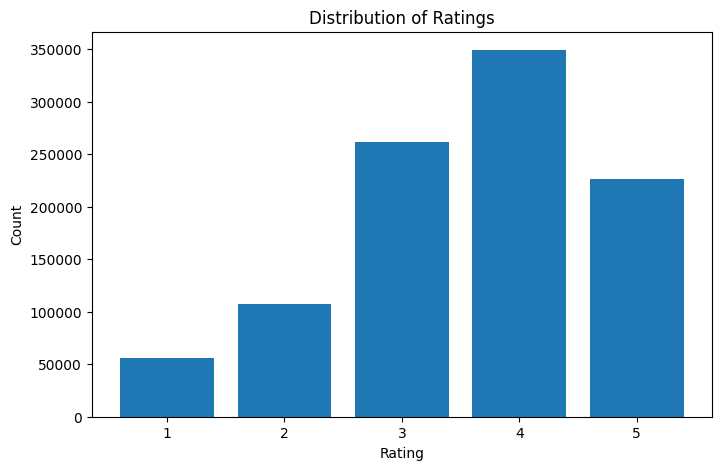

In [6]:
rating_dist = (
    ratings["rating"]
    .value_counts()
    .sort_index()
    .rename_axis("rating")
    .reset_index(name="count")
)

rating_dist["share"] = (rating_dist["count"] / rating_dist["count"].sum()).round(4)

display(rating_dist)

plt.figure(figsize=(8, 5))
plt.bar(rating_dist["rating"].astype(str), rating_dist["count"])
plt.xlabel("Rating")
plt.ylabel("Count")
plt.title("Distribution of Ratings")
plt.show()

### User analysis

In [7]:
user_activity = ratings.groupby("user_id").size()

print("User activity describe:")
display(user_activity.describe())

User activity describe:


count    6040.000000
mean      165.597517
std       192.747029
min        20.000000
25%        44.000000
50%        96.000000
75%       208.000000
max      2314.000000
dtype: float64

In [8]:
user_thresholds = [20, 30, 40, 50, 100]

rows = []
for t in user_thresholds:
    kept_user_ids = user_activity[user_activity >= t].index
    filtered = ratings[ratings["user_id"].isin(kept_user_ids)]

    filtered_user_activity = filtered.groupby("user_id").size()

    rows.append({
        "min_user_ratings": t,
        "users_kept": filtered["user_id"].nunique(),
        "movies_kept": filtered["movie_id"].nunique(),
        "ratings_kept": len(filtered),

        "share_users_kept": round(filtered["user_id"].nunique() / ratings["user_id"].nunique(), 4),
        "share_movies_kept": round(filtered["movie_id"].nunique() / ratings["movie_id"].nunique(), 4),
        "share_ratings_kept": round(len(filtered) / len(ratings), 4),

        "avg_ratings_per_user": round(len(filtered) / filtered["user_id"].nunique(), 2),
        "median_ratings_per_user": round(filtered_user_activity.median(), 2),
    })

user_threshold_effect = pd.DataFrame(rows)
display(user_threshold_effect)

,min_user_ratings,users_kept,movies_kept,ratings_kept,share_users_kept,share_movies_kept,share_ratings_kept,avg_ratings_per_user,median_ratings_per_user
0,20,6040,3706,1000209,1.0000,1.0000,1.0000,165.60,96.0
1,30,5289,3701,982040,0.8757,0.9987,0.9818,185.68,114.0
2,40,4737,3694,963023,0.7843,0.9968,0.9628,203.30,129.0
3,50,4297,3689,943471,0.7114,0.9954,0.9433,219.57,146.0
4,100,2945,3670,847302,0.4876,0.9903,0.8471,287.71,212.0


### Movie analysis

In [9]:
movie_activity = ratings.groupby("movie_id").size()

print("Movie activity describe:")
display(movie_activity.describe())

Movie activity describe:


count    3706.000000
mean      269.889099
std       384.047838
min         1.000000
25%        33.000000
50%       123.500000
75%       350.000000
max      3428.000000
dtype: float64

In [10]:
movie_thresholds = [1, 5, 10, 20, 40, 100]

rows = []
for t in movie_thresholds:
    kept_movie_ids = movie_activity[movie_activity >= t].index
    filtered = ratings[ratings["movie_id"].isin(kept_movie_ids)]

    filtered_movie_activity = filtered.groupby("movie_id").size()

    rows.append({
        "min_movie_ratings": t,
        "movies_kept": filtered["movie_id"].nunique(),
        "users_kept": filtered["user_id"].nunique(),
        "ratings_kept": len(filtered),

        "share_movies_kept": round(filtered["movie_id"].nunique() / ratings["movie_id"].nunique(), 4),
        "share_users_kept": round(filtered["user_id"].nunique() / ratings["user_id"].nunique(), 4),
        "share_ratings_kept": round(len(filtered) / len(ratings), 4),

        "avg_ratings_per_movie": round(len(filtered) / filtered["movie_id"].nunique(), 2),
        "median_ratings_per_movie": round(filtered_movie_activity.median(), 2),
    })

movie_threshold_effect = pd.DataFrame(rows)
display(movie_threshold_effect)

,min_movie_ratings,movies_kept,users_kept,ratings_kept,share_movies_kept,share_users_kept,share_ratings_kept,avg_ratings_per_movie,median_ratings_per_movie
0,1,3706,6040,1000209,1.0000,1.0,1.0000,269.89,123.5
1,5,3416,6040,999611,0.9217,1.0,0.9994,292.63,146.0
2,10,3260,6040,998539,0.8797,1.0,0.9983,306.30,161.0
3,20,3043,6040,995492,0.8211,1.0,0.9953,327.14,180.0
4,40,2673,6040,984878,0.7213,1.0,0.9847,368.45,219.0
5,100,2019,6040,942225,0.5448,1.0,0.9420,466.68,314.0


### Tie Analysis

In [11]:
rows = []

for user_id, group in ratings.groupby("user_id"):
    rating_counts = group["rating"].value_counts().to_dict()

    c1 = rating_counts.get(1, 0)
    c2 = rating_counts.get(2, 0)
    c3 = rating_counts.get(3, 0)
    c4 = rating_counts.get(4, 0)
    c5 = rating_counts.get(5, 0)

    n = len(group)

    total_pairs = comb(n, 2)

    tie_pairs = (
        comb(c1, 2) +
        comb(c2, 2) +
        comb(c3, 2) +
        comb(c4, 2) +
        comb(c5, 2)
    )

    near_tie_pairs = (
        c1 * c2 +
        c2 * c3 +
        c3 * c4 +
        c4 * c5
    )

    strong_pref_pairs = total_pairs - tie_pairs - near_tie_pairs
    non_equal_pairs = total_pairs - tie_pairs

    rows.append({
        "user_id": user_id,
        "items_rated": n,
        "total_pairs": total_pairs,
        "tie_pairs": tie_pairs,
        "near_tie_pairs": near_tie_pairs,
        "strong_pref_pairs": strong_pref_pairs,
        "non_equal_pairs": non_equal_pairs,
    })

tie_analysis_per_user = pd.DataFrame(rows)
display(tie_analysis_per_user.head())

,user_id,items_rated,total_pairs,tie_pairs,near_tie_pairs,strong_pref_pairs,non_equal_pairs
0,1,53,1378,532,702,144,846
1,2,129,8256,2261,3498,2497,5995
2,3,51,1275,378,568,329,897
3,4,21,210,73,90,47,137
4,5,198,19503,4671,7882,6950,14832


In [12]:
tie_summary = pd.DataFrame([{
    "users": tie_analysis_per_user["user_id"].nunique(),
    "total_pairs": tie_analysis_per_user["total_pairs"].sum(),
    "tie_pairs": tie_analysis_per_user["tie_pairs"].sum(),
    "near_tie_pairs": tie_analysis_per_user["near_tie_pairs"].sum(),
    "strong_pref_pairs": tie_analysis_per_user["strong_pref_pairs"].sum(),
    "non_equal_pairs": tie_analysis_per_user["non_equal_pairs"].sum(),
}])

tie_summary["tie_share"] = round(tie_summary["tie_pairs"] / tie_summary["total_pairs"], 4)
tie_summary["near_tie_share"] = round(tie_summary["near_tie_pairs"] / tie_summary["total_pairs"], 4)
tie_summary["strong_pref_share"] = round(tie_summary["strong_pref_pairs"] / tie_summary["total_pairs"], 4)
tie_summary["non_equal_share"] = round(tie_summary["non_equal_pairs"] / tie_summary["total_pairs"], 4)

display(tie_summary)

,users,total_pairs,tie_pairs,near_tie_pairs,strong_pref_pairs,non_equal_pairs,tie_share,near_tie_share,strong_pref_share,non_equal_share
0,6040,194494663,57371886,80774336,56348441,137122777,0.295,0.4153,0.2897,0.705


In [13]:
policy_summary = pd.DataFrame([
    {
        "policy": "diff >= 1",
        "pairs_kept": tie_analysis_per_user["non_equal_pairs"].sum(),
        "avg_pairs_per_user": round(tie_analysis_per_user["non_equal_pairs"].mean(), 2),
        "median_pairs_per_user": round(tie_analysis_per_user["non_equal_pairs"].median(), 2),
        "users_with_zero_pairs": int((tie_analysis_per_user["non_equal_pairs"] == 0).sum()),
        "users_with_less_than_10_pairs": int((tie_analysis_per_user["non_equal_pairs"] < 10).sum()),
        "users_with_less_than_50_pairs": int((tie_analysis_per_user["non_equal_pairs"] < 50).sum()),
    },
    {
        "policy": "diff >= 2",
        "pairs_kept": tie_analysis_per_user["strong_pref_pairs"].sum(),
        "avg_pairs_per_user": round(tie_analysis_per_user["strong_pref_pairs"].mean(), 2),
        "median_pairs_per_user": round(tie_analysis_per_user["strong_pref_pairs"].median(), 2),
        "users_with_zero_pairs": int((tie_analysis_per_user["strong_pref_pairs"] == 0).sum()),
        "users_with_less_than_10_pairs": int((tie_analysis_per_user["strong_pref_pairs"] < 10).sum()),
        "users_with_less_than_50_pairs": int((tie_analysis_per_user["strong_pref_pairs"] < 50).sum()),
    }
])

policy_summary["share_pairs_kept"] = round(
    policy_summary["pairs_kept"] / tie_analysis_per_user["total_pairs"].sum(), 4
)

display(policy_summary)

,policy,pairs_kept,avg_pairs_per_user,median_pairs_per_user,users_with_zero_pairs,users_with_less_than_10_pairs,users_with_less_than_50_pairs,share_pairs_kept
0,diff >= 1,137122777,22702.45,3071.0,0,0,4,0.7050
1,diff >= 2,56348441,9329.21,1102.0,11,15,191,0.2897


## 3. Filtering

In [14]:
min_user_ratings = 40
min_movie_ratings = 10

In [15]:
ratings_filtered = ratings.copy()

while True:
    prev_users = set(ratings_filtered["user_id"].unique())
    prev_movies = set(ratings_filtered["movie_id"].unique())

    user_activity = ratings_filtered.groupby("user_id").size()
    valid_users = user_activity[user_activity >= min_user_ratings].index
    ratings_filtered = ratings_filtered[ratings_filtered["user_id"].isin(valid_users)].copy()

    movie_activity = ratings_filtered.groupby("movie_id").size()
    valid_movies = movie_activity[movie_activity >= min_movie_ratings].index
    ratings_filtered = ratings_filtered[ratings_filtered["movie_id"].isin(valid_movies)].copy()

    new_users = set(ratings_filtered["user_id"].unique())
    new_movies = set(ratings_filtered["movie_id"].unique())

    if new_users == prev_users and new_movies == prev_movies:
        break

In [16]:
filtering_summary = pd.DataFrame([{
    "min_user_ratings": min_user_ratings,
    "min_movie_ratings": min_movie_ratings,
    "ratings_kept": len(ratings_filtered),
    "users_kept": ratings_filtered["user_id"].nunique(),
    "movies_kept": ratings_filtered["movie_id"].nunique(),
    "share_ratings_kept": round(len(ratings_filtered) / len(ratings), 4),
    "share_users_kept": round(ratings_filtered["user_id"].nunique() / ratings["user_id"].nunique(), 4),
    "share_movies_kept": round(ratings_filtered["movie_id"].nunique() / ratings["movie_id"].nunique(), 4),
    "avg_ratings_per_user": round(ratings_filtered.groupby("user_id").size().mean(), 2),
    "median_ratings_per_user": round(ratings_filtered.groupby("user_id").size().median(), 2),
    "avg_ratings_per_movie": round(ratings_filtered.groupby("movie_id").size().mean(), 2),
    "median_ratings_per_movie": round(ratings_filtered.groupby("movie_id").size().median(), 2),
}])

display(filtering_summary)

,min_user_ratings,min_movie_ratings,ratings_kept,users_kept,movies_kept,share_ratings_kept,share_users_kept,share_movies_kept,avg_ratings_per_user,median_ratings_per_user,avg_ratings_per_movie,median_ratings_per_movie
0,40,10,960916,4726,3250,0.9607,0.7825,0.877,203.33,129.0,295.67,158.0


In [17]:
final_user_counts = ratings_filtered.groupby("user_id").size()
final_movie_counts = ratings_filtered.groupby("movie_id").size()

print("All users satisfy min_user_ratings:", (final_user_counts >= min_user_ratings).all())
print("All movies satisfy min_movie_ratings:", (final_movie_counts >= min_movie_ratings).all())

All users satisfy min_user_ratings: True
All movies satisfy min_movie_ratings: True


We applied **iterative joint filtering** with the following thresholds:

- **Minimum user ratings:** 40
- **Minimum movie ratings:** 10

This choice removes sparse users and infrequent movies while preserving most of the interaction data.  
Filtering is performed iteratively because removing low-activity users can affect movie frequencies, and removing infrequent movies can in turn reduce some users below the user threshold. Therefore, both steps are repeated until the dataset becomes stable.

After iterative filtering, the final dataset contains:

- **4,726 users**
- **3,250 movies**
- **960,916 ratings**

This corresponds to retaining **96.07%** of ratings, **78.25%** of users, and **87.70%** of movies.  
All remaining users and movies satisfy the selected minimum activity thresholds.

## 4. Train Test Split

In [18]:
def temporal_split_by_timestamp_groups_strict(df, val_ratio=0.1, test_ratio=0.1):
    train_parts = []
    val_parts = []
    test_parts = []

    for user_id, user_df in df.groupby("user_id"):
        user_df = user_df.sort_values(["datetime", "movie_id"]).copy()

        time_blocks = [block for _, block in user_df.groupby("datetime", sort=True)]

        n_ratings = len(user_df)
        target_test = max(1, int(round(n_ratings * test_ratio)))
        target_val = max(1, int(round(n_ratings * val_ratio)))

        test_blocks = []
        test_count = 0
        i = len(time_blocks) - 1

        while i >= 0 and test_count < target_test:
            test_blocks.append(time_blocks[i])
            test_count += len(time_blocks[i])
            i -= 1

        val_blocks = []
        val_count = 0

        while i >= 0 and val_count < target_val:
            val_blocks.append(time_blocks[i])
            val_count += len(time_blocks[i])
            i -= 1

        train_blocks = time_blocks[:i + 1]

        if len(train_blocks) == 0 or len(val_blocks) == 0 or len(test_blocks) == 0:
            continue

        train_user = pd.concat(train_blocks, ignore_index=True)
        val_user = pd.concat(val_blocks[::-1], ignore_index=True)
        test_user = pd.concat(test_blocks[::-1], ignore_index=True)

        train_parts.append(train_user)
        val_parts.append(val_user)
        test_parts.append(test_user)

    train_df = pd.concat(train_parts, ignore_index=True)
    val_df = pd.concat(val_parts, ignore_index=True)
    test_df = pd.concat(test_parts, ignore_index=True)

    train_df = train_df.sort_values(["user_id", "datetime", "movie_id"]).reset_index(drop=True)
    val_df = val_df.sort_values(["user_id", "datetime", "movie_id"]).reset_index(drop=True)
    test_df = test_df.sort_values(["user_id", "datetime", "movie_id"]).reset_index(drop=True)

    # remove unseen movies from validation and test
    train_movies = set(train_df["movie_id"].unique())
    val_df = val_df[val_df["movie_id"].isin(train_movies)].copy()
    test_df = test_df[test_df["movie_id"].isin(train_movies)].copy()

    # keep only users that still have records in all three splits
    valid_users = (
        set(train_df["user_id"].unique())
        & set(val_df["user_id"].unique())
        & set(test_df["user_id"].unique())
    )

    train_df = train_df[train_df["user_id"].isin(valid_users)].copy()
    val_df = val_df[val_df["user_id"].isin(valid_users)].copy()
    test_df = test_df[test_df["user_id"].isin(valid_users)].copy()

    train_df = train_df.sort_values(["user_id", "datetime", "movie_id"]).reset_index(drop=True)
    val_df = val_df.sort_values(["user_id", "datetime", "movie_id"]).reset_index(drop=True)
    test_df = test_df.sort_values(["user_id", "datetime", "movie_id"]).reset_index(drop=True)

    return train_df, val_df, test_df

### Apply Splitting

In [19]:
train_df, val_df, test_df = temporal_split_by_timestamp_groups_strict(
    ratings_filtered,
    val_ratio=0.1,
    test_ratio=0.1
)

### Split Summury

In [20]:
split_summary = pd.DataFrame([
    {
        "split": "train",
        "rows": len(train_df),
        "users": train_df["user_id"].nunique(),
        "movies": train_df["movie_id"].nunique(),
    },
    {
        "split": "validation",
        "rows": len(val_df),
        "users": val_df["user_id"].nunique(),
        "movies": val_df["movie_id"].nunique(),
    },
    {
        "split": "test",
        "rows": len(test_df),
        "users": test_df["user_id"].nunique(),
        "movies": test_df["movie_id"].nunique(),
    },
])

split_summary["share_rows"] = round(split_summary["rows"] / len(ratings_filtered), 4)
display(split_summary)

,split,rows,users,movies,share_rows
0,train,759509,4726,3250,0.7904
1,validation,100817,4726,3204,0.1049
2,test,100590,4726,3226,0.1047


## 5. Pre-Pairwise Generation Analysis

### User coverage

In [21]:
train_users = set(train_df["user_id"].unique())
val_users = set(val_df["user_id"].unique())
test_users = set(test_df["user_id"].unique())

print("All validation users are in train:", val_users.issubset(train_users))
print("All test users are in train:", test_users.issubset(train_users))
print("All test users are in validation:", test_users.issubset(val_users))

All validation users are in train: True
All test users are in train: True
All test users are in validation: True


### Movie coverage

In [22]:
train_movies = set(train_df["movie_id"].unique())
val_movies = set(val_df["movie_id"].unique())
test_movies = set(test_df["movie_id"].unique())

print("All validation movies are in train:", val_movies.issubset(train_movies))
print("All test movies are in train:", test_movies.issubset(train_movies))
print("All test movies are in validation:", test_movies.issubset(val_movies))

All validation movies are in train: True
All test movies are in train: True
All test movies are in validation: False


### Overlap

In [23]:
train_idx = set(zip(train_df["user_id"], train_df["movie_id"], train_df["timestamp"]))
val_idx = set(zip(val_df["user_id"], val_df["movie_id"], val_df["timestamp"]))
test_idx = set(zip(test_df["user_id"], test_df["movie_id"], test_df["timestamp"]))

print("Train/Validation overlap:", len(train_idx & val_idx))
print("Train/Test overlap:", len(train_idx & test_idx))
print("Validation/Test overlap:", len(val_idx & test_idx))

Train/Validation overlap: 0
Train/Test overlap: 0
Validation/Test overlap: 0


### Same timestamp group integrity

In [24]:
train_groups = train_df[["user_id", "timestamp"]].drop_duplicates().assign(split="train")
val_groups = val_df[["user_id", "timestamp"]].drop_duplicates().assign(split="val")
test_groups = test_df[["user_id", "timestamp"]].drop_duplicates().assign(split="test")

all_groups = pd.concat([train_groups, val_groups, test_groups], ignore_index=True)
group_conflicts = all_groups.groupby(["user_id", "timestamp"])["split"].nunique()

print("Timestamp groups split across multiple sets:", int((group_conflicts > 1).sum()))

Timestamp groups split across multiple sets: 0


### Temporal train/validation/test split

We split the filtered dataset **separately for each user** in chronological order.

All interactions of the same user with the **same timestamp** are kept in the **same split**, so no timestamp group is broken across train, validation, and test.

For each user:
- the most recent timestamp blocks are assigned to the **test** set,
- the previous timestamp blocks are assigned to the **validation** set,
- the earlier history is assigned to the **training** set.

Users for whom a valid non-empty **train / validation / test** split cannot be created are removed from the final split.

To avoid **item cold-start** during evaluation, we keep in validation and test only those interactions whose movies also appear in the training set. After that, we retain only users that still have records in all three splits.

This gives a structurally consistent split:
- every retained user appears in **train**, **validation**, and **test**,
- all validation and test movies are **seen in training**,
- there is **no overlap** between splits,
- same-timestamp user interactions are **never split across sets**.

### Pair generation simulation

In [25]:
# Part 1. Exact number of valid train pairs per user (rating_diff >= 2)

pair_min_diff = 2

rows = []

for user_id, group in train_df.groupby("user_id"):
    rating_counts = group["rating"].value_counts().to_dict()

    c1 = rating_counts.get(1, 0)
    c2 = rating_counts.get(2, 0)
    c3 = rating_counts.get(3, 0)
    c4 = rating_counts.get(4, 0)
    c5 = rating_counts.get(5, 0)

    valid_pairs = (
        c5 * c3 + c5 * c2 + c5 * c1 +
        c4 * c2 + c4 * c1 +
        c3 * c1
    )

    rows.append({
        "user_id": user_id,
        "ratings_in_train": len(group),
        "pairs_diff_ge_2": valid_pairs,
        "count_1": c1,
        "count_2": c2,
        "count_3": c3,
        "count_4": c4,
        "count_5": c5,
    })

train_user_pair_stats = pd.DataFrame(rows)
display(train_user_pair_stats.head())

,user_id,ratings_in_train,pairs_diff_ge_2,count_1,count_2,count_3,count_4,count_5
0,1,42,84,0,0,6,22,14
1,2,101,1452,2,7,24,35,33
2,3,40,146,1,1,7,20,11
3,5,156,4369,17,19,49,51,20
4,6,54,280,1,1,16,24,12


### Distribution of pairs per user

In [26]:
# Part 2. Distribution overview of valid train pairs per user

pair_describe = train_user_pair_stats["pairs_diff_ge_2"].describe().to_frame(name="pairs_diff_ge_2")
display(pair_describe)

pair_percentiles = (
    train_user_pair_stats["pairs_diff_ge_2"]
    .quantile([0.50, 0.75, 0.90, 0.95, 0.99])
    .to_frame(name="pairs_diff_ge_2")
)

display(pair_percentiles)

,pairs_diff_ge_2
count,4726.000000
mean,7376.508887
std,20164.944108
min,0.000000
25%,382.000000
50%,1273.000000
75%,5442.250000
max,464230.000000


,pairs_diff_ge_2
0.50,1273.00
0.75,5442.25
0.90,18030.00
0.95,35132.25
0.99,91354.25


### Tail concentration

In [27]:
# Part 3. Tail concentration of valid train pairs

pair_col = "pairs_diff_ge_2"

sorted_pairs = (
    train_user_pair_stats[pair_col]
    .sort_values(ascending=False)
    .reset_index(drop=True)
)

total_pairs = sorted_pairs.sum()

top_1pct_n = max(1, int(round(len(sorted_pairs) * 0.01)))
top_5pct_n = max(1, int(round(len(sorted_pairs) * 0.05)))
top_10pct_n = max(1, int(round(len(sorted_pairs) * 0.10)))

tail_summary = pd.DataFrame([
    {
        "group": "top 1% users",
        "n_users": top_1pct_n,
        "pairs_share": round(sorted_pairs.iloc[:top_1pct_n].sum() / total_pairs, 4),
    },
    {
        "group": "top 5% users",
        "n_users": top_5pct_n,
        "pairs_share": round(sorted_pairs.iloc[:top_5pct_n].sum() / total_pairs, 4),
    },
    {
        "group": "top 10% users",
        "n_users": top_10pct_n,
        "pairs_share": round(sorted_pairs.iloc[:top_10pct_n].sum() / total_pairs, 4),
    },
])

display(tail_summary)

,group,n_users,pairs_share
0,top 1% users,47,0.2050
1,top 5% users,236,0.4991
2,top 10% users,473,0.6722


### Low-pair users

In [28]:
def summarize_low_pair_thresholds(pair_series, thresholds):
    n_users = len(pair_series)
    rows = []

    for t in thresholds:
        if t == 0:
            count = int((pair_series == 0).sum())
            label = "users with == 0 pairs"
        else:
            count = int((pair_series < t).sum())
            label = f"users with < {t} pairs"

        rows.append({
            "threshold": t,
            "group": label,
            "count": count,
            "share_users": round(count / n_users, 4),
        })

    return pd.DataFrame(rows)

In [29]:
low_pair_thresholds = [0, 5, 10, 20, 50, 100, 200, 500]

low_pair_summary = summarize_low_pair_thresholds(
    train_user_pair_stats["pairs_diff_ge_2"],
    thresholds=low_pair_thresholds
)

display(low_pair_summary)

,threshold,group,count,share_users
0,0,users with == 0 pairs,3,0.0006
1,5,users with < 5 pairs,3,0.0006
2,10,users with < 10 pairs,4,0.0008
3,20,users with < 20 pairs,5,0.0011
4,50,users with < 50 pairs,28,0.0059
5,100,users with < 100 pairs,149,0.0315
6,200,users with < 200 pairs,569,0.1204
7,500,users with < 500 pairs,1437,0.3041


### High-pair users

In [30]:
def summarize_high_pair_thresholds(pair_series, thresholds):
    n_users = len(pair_series)
    rows = []

    for t in thresholds:
        count = int((pair_series >= t).sum())

        rows.append({
            "threshold": t,
            "group": f"users with >= {t} pairs",
            "count": count,
            "share_users": round(count / n_users, 4),
        })

    return pd.DataFrame(rows)

In [31]:
high_pair_thresholds = [500, 1000, 2000, 5000, 10000, 20000, 50000, 100000]

high_pair_summary = summarize_high_pair_thresholds(
    train_user_pair_stats["pairs_diff_ge_2"],
    thresholds=high_pair_thresholds
)

display(high_pair_summary)

,threshold,group,count,share_users
0,500,users with >= 500 pairs,3289,0.6959
1,1000,users with >= 1000 pairs,2623,0.5550
2,2000,users with >= 2000 pairs,1953,0.4132
3,5000,users with >= 5000 pairs,1243,0.2630
4,10000,users with >= 10000 pairs,763,0.1614
5,20000,users with >= 20000 pairs,435,0.0920
6,50000,users with >= 50000 pairs,145,0.0307
7,100000,users with >= 100000 pairs,38,0.0080


In [32]:
def simulate_train_pair_policy(pair_series, min_thresholds, max_thresholds):
    total_users = len(pair_series)
    total_pairs = pair_series.sum()

    rows = []

    for min_t in min_thresholds:
        eligible = pair_series[pair_series >= min_t].copy()
        users_removed_by_min = total_users - len(eligible)

        for max_t in max_thresholds:
            if max_t is None:
                kept = eligible.copy()
                max_label = "all"
                users_affected_by_max = 0
            else:
                kept = eligible.clip(upper=max_t)
                max_label = max_t
                users_affected_by_max = int((eligible > max_t).sum())

            rows.append({
                "min_pairs_per_user": min_t,
                "max_pairs_per_user": max_label,
                "users_kept": int(len(eligible)),
                "share_users_kept": round(len(eligible) / total_users, 4),
                "pairs_kept_total": int(kept.sum()),
                "share_pairs_kept": round(kept.sum() / total_pairs, 4),
                "avg_pairs_per_user": round(kept.mean(), 2) if len(kept) > 0 else 0,
                "median_pairs_per_user": round(kept.median(), 2) if len(kept) > 0 else 0,
                "users_removed_by_min": int(users_removed_by_min),
                "users_affected_by_max": int(users_affected_by_max),
            })

    return pd.DataFrame(rows)

In [33]:
train_pair_policy_simulation = simulate_train_pair_policy(
    train_user_pair_stats["pairs_diff_ge_2"],
    min_thresholds=[0, 10, 30, 50, 70, 100],
    max_thresholds=[200, 500, 1000, 2000, 5000, 10000, None]
)

display(train_pair_policy_simulation)

,min_pairs_per_user,max_pairs_per_user,users_kept,share_users_kept,pairs_kept_total,share_pairs_kept,avg_pairs_per_user,median_pairs_per_user,users_removed_by_min,users_affected_by_max
0,0,200,4726,1.0000,905498,0.0260,191.60,200.0,0,4148
1,0,500,4726,1.0000,2002095,0.0574,423.63,500.0,0,3287
2,0,1000,4726,1.0000,3454616,0.0991,730.98,1000.0,0,2623
3,0,2000,4726,1.0000,5692252,0.1633,1204.45,1273.0,0,1951
4,0,5000,4726,1.0000,10300774,0.2955,2179.60,1273.0,0,1243
5,0,10000,4726,1.0000,15161663,0.4349,3208.14,1273.0,0,761
6,0,all,4726,1.0000,34861381,1.0000,7376.51,1273.0,0,0
7,10,200,4722,0.9992,905490,0.0260,191.76,200.0,4,4148
8,10,500,4722,0.9992,2002087,0.0574,423.99,500.0,4,3287
9,10,1000,4722,0.9992,3454608,0.0991,731.60,1000.0,4,2623


Simulation of train pair filtering policy

To choose the final pair construction policy for the training set, we simulate combinations of:

- a **minimum number of pairs per user**, which removes users with too little pairwise signal,
- a **maximum number of pairs per user**, which limits the contribution of very active users and reduces pair explosion.

This allows us to compare user coverage and retained training signal under different train pair policies before constructing the final sampled training pairs.

## 6. Pairwise Generation 

In [34]:
pair_min_diff = 2

train_min_pairs_per_user = 10
train_max_pairs_per_user = 2000

random_seed = 42

In [35]:
def generate_pairwise_data(
    df,
    pair_min_diff=2,
    min_pairs_per_user=None,
    max_pairs_per_user=None,
    seed=42
):
    all_rows = []

    for user_id, user_df in df.groupby("user_id"):
        user_df = user_df.sort_values(["datetime", "movie_id"]).copy()

        rating_buckets = {}
        for rating, bucket in user_df.groupby("rating"):
            rating_buckets[rating] = bucket[["movie_id", "timestamp"]].values.tolist()

        user_pairs = []

        for high_rating in [5, 4, 3, 2, 1]:
            for low_rating in [5, 4, 3, 2, 1]:
                if high_rating - low_rating < pair_min_diff:
                    continue

                high_items = rating_buckets.get(high_rating, [])
                low_items = rating_buckets.get(low_rating, [])

                if len(high_items) == 0 or len(low_items) == 0:
                    continue

                for (pos_item, pos_ts), (neg_item, neg_ts) in product(high_items, low_items):
                    user_pairs.append({
                        "user_id": user_id,
                        "pos_item": int(pos_item),
                        "neg_item": int(neg_item),
                        "rating_pos": int(high_rating),
                        "rating_neg": int(low_rating),
                        "rating_diff": int(high_rating - low_rating),
                        "timestamp_pos": int(pos_ts),
                        "timestamp_neg": int(neg_ts),
                    })

        if min_pairs_per_user is not None and len(user_pairs) < min_pairs_per_user:
            continue

        if max_pairs_per_user is not None and len(user_pairs) > max_pairs_per_user:
            rng = random.Random(seed + int(user_id))
            selected_idx = rng.sample(range(len(user_pairs)), max_pairs_per_user)
            user_pairs = [user_pairs[i] for i in selected_idx]

        all_rows.extend(user_pairs)

    pair_df = pd.DataFrame(all_rows)

    if len(pair_df) > 0:
        pair_df = pair_df.sort_values(
            ["user_id", "timestamp_pos", "timestamp_neg", "pos_item", "neg_item"]
        ).reset_index(drop=True)

    return pair_df

In [36]:
train_pairs = generate_pairwise_data(
    train_df,
    pair_min_diff=pair_min_diff,
    min_pairs_per_user=train_min_pairs_per_user,
    max_pairs_per_user=train_max_pairs_per_user,
    seed=random_seed
)

display(train_pairs.head())
print("Train pairs shape:", train_pairs.shape)

,user_id,pos_item,neg_item,rating_pos,rating_neg,rating_diff,timestamp_pos,timestamp_neg
0,1,1022,2340,5,3,2,978300055,978300103
1,1,1270,2340,5,3,2,978300055,978300103
2,1,1022,720,5,3,2,978300055,978300760
3,1,1270,720,5,3,2,978300055,978300760
4,1,1022,914,5,3,2,978300055,978301968


Train pairs shape: (5692244, 8)


In [37]:
val_pairs = generate_pairwise_data(
    val_df,
    pair_min_diff=pair_min_diff,
    min_pairs_per_user=None,
    max_pairs_per_user=None,
    seed=random_seed
)

test_pairs = generate_pairwise_data(
    test_df,
    pair_min_diff=pair_min_diff,
    min_pairs_per_user=None,
    max_pairs_per_user=None,
    seed=random_seed
)

print("Validation pairs shape:", val_pairs.shape)
print("Test pairs shape:", test_pairs.shape)

Validation pairs shape: (478099, 8)
Test pairs shape: (507550, 8)


In [38]:
def summarize_pair_dataset(pair_df, split_name):
    if len(pair_df) == 0:
        return {
            "split": split_name,
            "pairs": 0,
            "users_with_pairs": 0,
            "avg_pairs_per_user": 0,
            "median_pairs_per_user": 0,
            "min_pairs_per_user": 0,
            "max_pairs_per_user": 0,
        }

    user_pair_counts = pair_df.groupby("user_id").size()

    return {
        "split": split_name,
        "pairs": int(len(pair_df)),
        "users_with_pairs": int(pair_df["user_id"].nunique()),
        "avg_pairs_per_user": round(user_pair_counts.mean(), 2),
        "median_pairs_per_user": round(user_pair_counts.median(), 2),
        "min_pairs_per_user": int(user_pair_counts.min()),
        "max_pairs_per_user": int(user_pair_counts.max()),
    }

pair_summary = pd.DataFrame([
    summarize_pair_dataset(train_pairs, "train"),
    summarize_pair_dataset(val_pairs, "validation"),
    summarize_pair_dataset(test_pairs, "test"),
])

display(pair_summary)

,split,pairs,users_with_pairs,avg_pairs_per_user,median_pairs_per_user,min_pairs_per_user,max_pairs_per_user
0,train,5692244,4722,1205.47,1277.5,18,2000
1,validation,478099,4159,114.96,25.0,1,6620
2,test,507550,4164,121.89,27.0,1,6954


In [39]:
print("All train rating_diff >= 2:", (train_pairs["rating_diff"] >= 2).all())
print("All validation rating_diff >= 2:", (val_pairs["rating_diff"] >= 2).all())
print("All test rating_diff >= 2:", (test_pairs["rating_diff"] >= 2).all())

print("Unique train users in pair data:", train_pairs["user_id"].nunique())
print("Unique validation users in pair data:", val_pairs["user_id"].nunique())
print("Unique test users in pair data:", test_pairs["user_id"].nunique())

All train rating_diff >= 2: True
All validation rating_diff >= 2: True
All test rating_diff >= 2: True
Unique train users in pair data: 4722
Unique validation users in pair data: 4159
Unique test users in pair data: 4164


In [40]:
print("Train duplicate pair rows:", train_pairs.duplicated().sum())
print("Validation duplicate pair rows:", val_pairs.duplicated().sum())
print("Test duplicate pair rows:", test_pairs.duplicated().sum())

Train duplicate pair rows: 0
Validation duplicate pair rows: 0
Test duplicate pair rows: 0


Using the selected pair construction policy (`rating difference >= 2`), we generated separate pairwise datasets for train, validation, and test.

For the training split, we applied:
- **minimum pairs per user:** 10
- **maximum pairs per user:** 2000

This produced a capped training pair dataset that preserves broad user coverage while limiting domination by very active users.

For validation and test, we kept all valid pairs without a user-level cap, so that pairwise evaluation reflects the full held-out signal available under the chosen preference rule.

As expected, not every retained split user appears in the final validation/test pair datasets, because some users do not have any valid pairwise comparisons with rating difference >= 2 in those splits.

In [41]:
pair_coverage_summary = pd.DataFrame([
    {
        "split": "validation",
        "users_in_split": val_df["user_id"].nunique(),
        "users_with_pairs": val_pairs["user_id"].nunique(),
        "share_users_with_pairs": round(val_pairs["user_id"].nunique() / val_df["user_id"].nunique(), 4),
    },
    {
        "split": "test",
        "users_in_split": test_df["user_id"].nunique(),
        "users_with_pairs": test_pairs["user_id"].nunique(),
        "share_users_with_pairs": round(test_pairs["user_id"].nunique() / test_df["user_id"].nunique(), 4),
    },
])

display(pair_coverage_summary)

,split,users_in_split,users_with_pairs,share_users_with_pairs
0,validation,4726,4159,0.8800
1,test,4726,4164,0.8811


Pairwise coverage in validation and test

Not every user in validation and test interaction splits has at least one valid pairwise comparison under the selected rule `rating difference >= 2`.

This is expected: some users have held-out interactions, but no strong preference pair after excluding ties and near-ties. Therefore, pairwise validation and test evaluation is performed only on users who have at least one valid pair in the corresponding split.

In our final data, pairwise coverage is about **88.0%** of validation users and **88.1%** of test users.

In [42]:
%pip install pyarrow

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.0.1 -> 26.1
[notice] To update, run: python.exe -m pip install --upgrade pip


## 7. Save Results

In [43]:
results_dir = "./results01"
os.makedirs(results_dir, exist_ok=True)

# Save summary tables
filtering_summary.to_csv(f"{results_dir}/filtering_summary.csv", index=False)
split_summary.to_csv(f"{results_dir}/split_summary.csv", index=False)

pair_describe.to_csv(f"{results_dir}/train_pair_describe.csv")
pair_percentiles.to_csv(f"{results_dir}/train_pair_percentiles.csv")

low_pair_summary.to_csv(f"{results_dir}/train_low_pair_summary.csv", index=False)
high_pair_summary.to_csv(f"{results_dir}/train_high_pair_summary.csv", index=False)
tail_summary.to_csv(f"{results_dir}/train_tail_summary.csv", index=False)
train_pair_policy_simulation.to_csv(f"{results_dir}/train_pair_policy_simulation.csv", index=False)

pair_summary.to_csv(f"{results_dir}/pair_summary.csv", index=False)
pair_coverage_summary.to_csv(f"{results_dir}/pair_coverage_summary.csv", index=False)

# Save large datasets
ratings_filtered.to_parquet(f"{results_dir}/ratings_filtered.parquet", index=False)

train_df.to_parquet(f"{results_dir}/train_split.parquet", index=False)
val_df.to_parquet(f"{results_dir}/validation_split.parquet", index=False)
test_df.to_parquet(f"{results_dir}/test_split.parquet", index=False)

train_pairs.to_parquet(f"{results_dir}/train_pairs.parquet", index=False)
val_pairs.to_parquet(f"{results_dir}/validation_pairs.parquet", index=False)
test_pairs.to_parquet(f"{results_dir}/test_pairs.parquet", index=False)

print("Saved results to", results_dir)

Saved results to ./results01
